<a href="https://colab.research.google.com/github/andreaprifti19/SINDy-Teaching-Usecases/blob/main/notebooks/01_damped_oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 3.3 MB/s eta 0:00:00


In [2]:
import warnings

import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import LinAlgWarning
from sklearn.metrics import mean_absolute_error
from sklearn.exceptions import ConvergenceWarning
import pysindy as ps

# STLSQ routinely raises these two in the robustness sweeps.They are
# suppressed so the sweep tables stay readable; any other warning still
# reaches us.

warnings.filterwarnings("ignore", category=LinAlgWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Fixed seed -> identical noise, identical numbers, on every run and every
# machine.
SEED = 0
rng = np.random.default_rng(SEED)

print("pysindy      ", ps.__version__)
print("numpy        ", np.__version__)
print("scipy        ", scipy.__version__)
print("scikit-learn ", sklearn.__version__)
print("matplotlib   ", matplotlib.__version__)

pysindy       2.1.0
numpy         2.1.3
scipy         1.16.3
scikit-learn  1.6.1
matplotlib    3.10.0


In [3]:
m = 1.0   # mass
k = 2.0   # spring constant
c = 0.3   # damping coefficient

def damped_oscillator(t, state):
    x, v = state
    return [v, -(k / m) * x - (c / m) * v]

# The answer we want SINDy to recover, written as a coefficient matrix.
# Rows = equations (x', v'); columns = library terms [1, x, v, x^2, x*v, v^2].
TRUE_COEF = np.array([
    [0.0,  0.0,   1.0,   0.0, 0.0, 0.0],   # x' = v
    [0.0, -k/m,  -c/m,   0.0, 0.0, 0.0],   # v' = -(k/m) x - (c/m) v
])

In [4]:
dt = 0.01                        # sampling interval
t = np.arange(0, 25, dt)         # 25 s ≈ 5.6 oscillation periods
x0 = [2.0, 0.0]                  # released from x = 2 at rest

sol = solve_ivp(damped_oscillator, (t[0], t[-1]), x0, t_eval=t, rtol=1e-10, atol=1e-12)
X = sol.y.T                      # shape (n_samples, 2): column 0 = x, column 1 = v

print("Data matrix shape:", X.shape)

Data matrix shape: (2500, 2)


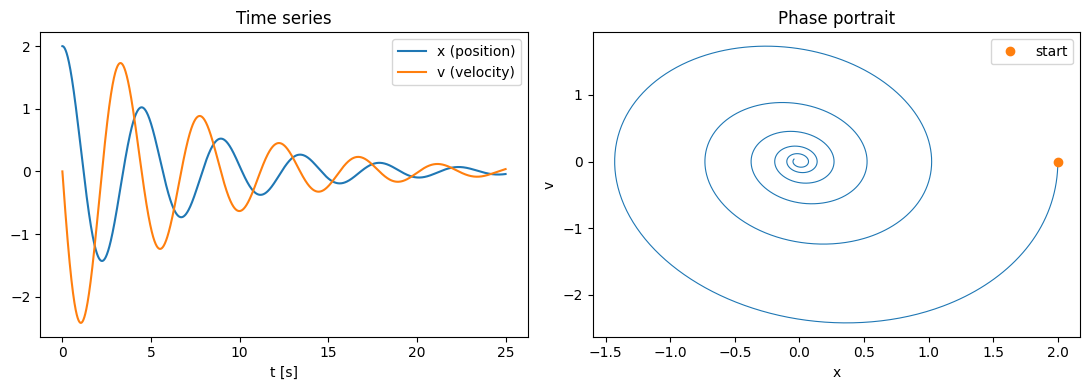

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, X[:, 0], label="x (position)")
ax[0].plot(t, X[:, 1], label="v (velocity)")
ax[0].set_xlabel("t [s]"); ax[0].legend(); ax[0].set_title("Time series")
ax[1].plot(X[:, 0], X[:, 1], lw=0.8)
ax[1].plot(X[0, 0], X[0, 1], "o", label="start")
ax[1].set_xlabel("x"); ax[1].set_ylabel("v"); ax[1].legend(); ax[1].set_title("Phase portrait")
plt.tight_layout(); plt.show()